# 05 - Strategy: production wait-for-TP

The strategy in one sentence: at every 20-min model boundary, if `p >= threshold`,
open a long lot with a GTC TP limit at `entry * exp(+phi)`. Hold until the
limit fills. Never close at a loss.

**Why this design and not the spec-ladder I tried first**

Earlier iterations imposed an exit horizon at M=20 minutes (label-aligned),
plus bulk-close on regime drop, plus per-position MTM stop. Every one of
those made the strategy *choose to sell* at unfavorable prices, and every
one of those choices was a realized loss the strategy didn't have to take.
With a fixed +phi target and any positive-vol process, the +phi level
materializes with probability approaching 1 as holding time grows. The
strategy is essentially harvesting upside excursions; the only "active"
decision is *when to enter*.

**Causality / production discipline enforced here**

- Parameters frozen at deployment time; no tuning on val/test data.
- Threshold is a fixed value (0.30) derived from offline analysis of
  the training-period score distribution — not from a quantile of val/test.
- Simulator runs val + test as a single chronological stream.
- Decision-time State uses only data observable at or before the boundary.
- TP fill uses 1-min bar high (= live execution monitoring at the base
  cadence) — first crossing fills at the limit price, deterministic.
- No look-ahead in any decision; post-hoc analytics that *do* peek at
  future paths (time-to-TP, worst-MTM) are clearly labeled as such.

**Headline numbers from the most recent run**
~~~
104-day deployment span         | val + test as one live stream
744 signals at p >= 0.30 fired  | 721 TPs filled (97%); 23 still open at end
Realized P&L:  +2.88% in 104d   | ~10.1% annualized
Peak capital:  78% of cap       | avg 25.7%, peak 39 of 50 concurrent
Worst paper DD: -10.0% on total equity (open book never realized)
BTC B&H over same period:       | -29% (a sharp bear period)
~~~

The +10%/yr is real income generated in a -29% market. The strategy is
*structurally long-biased* — the unrealized book is long-correlated — so
this is not delta-neutral alpha. The honest single-number summary:
**Calmar ratio ≈ 1.0** (annualized realized return / worst paper DD).


In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
    if (ROOT.parent / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError("Could not locate repo root")
sys.path.insert(0, str(ROOT))

from src import utils
from src.strategy.cache import (
    augment_cache_with_boundary_ohlc,
    augment_cache_with_r_realized,
)
from src.strategy.policy import (
    RiskConfig,
    StrategySpec,
    exit_tp_or_expiry,
    gate_score_above,
    score_raw_p,
    size_clip,
    size_constant,
)
from src.strategy.simulator import SimConfig, simulate

DATASET_DIR = ROOT / "data" / "model_dataset"
CACHE_PATH = DATASET_DIR / "research_predictions.parquet"
RAW_PATH = ROOT / "data" / "raw_data" / "klines_1m.parquet"
OUT_DIR = DATASET_DIR / "strategy" / "production"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)
print("ROOT     :", ROOT)
print("CACHE    :", CACHE_PATH)
print("RAW BARS :", RAW_PATH)
print("OUT_DIR  :", OUT_DIR)


ROOT     : C:\Users\vitil\OneDrive\Desktop\barrier_classifier
CACHE    : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\research_predictions.parquet
RAW BARS : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\raw_data\klines_1m.parquet
OUT_DIR  : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production


## 1. Frozen production parameters

Chosen before deployment; never tuned on val/test. `THRESHOLD` is the only
data-derived knob — its value comes from the model's `p` distribution on
the *training* period, which the model was fit on. The other knobs come
from contract definitions (`PHI`, `COST`) or operational risk
considerations (lot size, max concurrent).


In [2]:
# ----- Strategy contract -------------------------------------------------
THRESHOLD = 0.30        # ~ top-decile of p from training-period analysis
LOT_SIZE = 0.02         # 2% of nominal capital per lot
MAX_CONCURRENT = 50     # max gross deployment = 100% of capital
PHI = float(utils.PHI)  # 0.0025 = +25 bp upper barrier
COST = 0.0005           # 5 bp round-trip execution cost

# ----- Backstops kept off in v1 -----------------------------------------
USE_PER_POSITION_SL = False   # no per-position stop-loss
USE_BULK_CLOSE = False        # no regime-driven flatten
MAX_HORIZON_BOUNDARIES = 1_000_000   # effectively no time-based expiry

print(f"Threshold     : p >= {THRESHOLD}")
print(f"TP barrier    : +{PHI*1e4:.0f} bp  (cost {COST*1e4:.0f} bp/trade)")
print(f"Per-fill net  : +{(PHI-COST)*1e4:.0f} bp * lot_size")
print(f"Capital model : lot={LOT_SIZE} of cap, max_open={MAX_CONCURRENT} -> max gross = {LOT_SIZE*MAX_CONCURRENT*100:.0f}% of cap")


Threshold     : p >= 0.3
TP barrier    : +25 bp  (cost 5 bp/trade)
Per-fill net  : +20 bp * lot_size
Capital model : lot=0.02 of cap, max_open=50 -> max gross = 100% of cap


## 2. Load cache + raw bars; augment

Boundary cache is the model's prediction stream (every 20 min).
Raw bars are the 1-min OHLC stream used for path simulation and live
TP monitoring. `r_realized` is the per-boundary realized horizon return
for any later analytics that want it.


In [3]:
cache = pd.read_parquet(CACHE_PATH)
print(f"Cache rows: {len(cache):,}  cols: {len(cache.columns)}")
print(f"Splits   : {cache['split'].value_counts().to_dict()}")

raw_bars = pd.read_parquet(RAW_PATH, columns=["open", "high", "low", "close"])
print(f"Raw bars : {len(raw_bars):,}  range {raw_bars.index.min()} -> {raw_bars.index.max()}")

cache = augment_cache_with_boundary_ohlc(cache, raw_bars)
cache = augment_cache_with_r_realized(cache, raw_bars, M=int(utils.M))
print(f"After augmentation: {list(cache.columns)}")


Cache rows: 7,462  cols: 9
Splits   : {'test': 3731, 'val': 3731}
Raw bars : 525,600  range 2025-01-01 00:01:00+00:00 -> 2026-01-01 00:00:00+00:00
After augmentation: ['k', 'ts', 'y', 'm_k', 'tau_k', 'phi', 'regime', 'p', 'split', 'open', 'high', 'low', 'close', 'r_realized']


## 3. Define the production spec and run on val + test stream

The spec is intentionally minimal: one entry gate (`p >= threshold`), TP
limit exit, no bulk-close, no SL, no horizon expiry within the data span.
The simulator processes boundaries chronologically; intra-boundary 1-min
bars resolve any TPs that fire between two boundaries.


In [4]:
sim_cache = (
    pd.concat([cache[cache['split']=='val'], cache[cache['split']=='test']])
    .sort_values('ts').reset_index(drop=True)
)
val_test_boundary = cache[cache['split'] == 'test']['ts'].min()
print(f"Live stream: {sim_cache['ts'].min()} -> {sim_cache['ts'].max()}  ({len(sim_cache):,} boundaries)")
print(f"val | test split point: {val_test_boundary}")

spec = StrategySpec(
    name='production_wait_for_tp',
    score_fn=score_raw_p,
    entry_gates=(lambda s: gate_score_above(s, THRESHOLD),),
    sizer=lambda s: size_clip(size_constant(s, default=LOT_SIZE), max_size=1.0),
    exit_policy=exit_tp_or_expiry,
    bulk_close=lambda s: None,
    risk=RiskConfig(
        cost_per_trade=COST,
        max_open_positions=MAX_CONCURRENT,
        max_gross_size=MAX_CONCURRENT * LOT_SIZE + 1e-6,
        max_horizon_boundaries=MAX_HORIZON_BOUNDARIES,
        position_mtm_floor_log_return=None,
    ),
)

cfg = SimConfig(M=int(utils.M))
t0 = time.perf_counter()
result = simulate(sim_cache, raw_bars, spec, config=cfg)
print(f"Simulator: {time.perf_counter()-t0:.1f}s   trades closed={len(result.closed)}, open at end={int(result.equity['n_open'].iloc[-1])}")


Live stream: 2025-09-18 12:21:00 -> 2025-12-31 23:21:00  (7,462 boundaries)
val | test split point: 2025-11-10 04:01:00


Simulator: 21.9s   trades closed=721, open at end=23


## 4. Production-grade headline metrics

Everything reported here is observable at the end-of-period in real
deployment. The deterministic +`(phi-cost)*lot_size` per TP fill makes the
realized side a one-way ratchet by construction.


In [5]:
eq = result.equity.copy()
eq['ts'] = pd.to_datetime(eq['ts'])
span_days = (eq['ts'].max() - eq['ts'].min()).total_seconds() / 86400.0

# Realized P&L per actual calendar day (for Sharpe-of-realized)
eq_idx = eq.set_index('ts')
daily = eq_idx['realized_cum'].resample('1D').last().ffill()
daily_ret = daily.diff().fillna(daily.iloc[0])
annualized_realized = float(daily.iloc[-1]) * (365.0 / span_days)
sharpe_realized = (
    float(daily_ret.mean() / daily_ret.std() * np.sqrt(365.0))
    if daily_ret.std() > 1e-18 else float('nan')
)

# Capital utilization
eq['utilization'] = eq['gross_size'] / (MAX_CONCURRENT * LOT_SIZE)
peak_util = float(eq['utilization'].max())
avg_util = float(eq['utilization'].mean())
peak_concurrent = int(eq['n_open'].max())

# Worst paper drawdown on TOTAL equity (realized + unrealized; observable live)
total_eq = (eq['realized_cum'] + eq['unrealized']).to_numpy()
peaks = np.maximum.accumulate(total_eq)
dd_series = total_eq - peaks
max_paper_dd = float(-dd_series.min())

# BTC buy-and-hold baseline over the same period
raw_idx = raw_bars.index.tz_localize(None) if raw_bars.index.tz is not None else raw_bars.index
n0 = int(np.searchsorted(raw_idx, np.datetime64(eq['ts'].min()), side='left'))
n1 = int(np.searchsorted(raw_idx, np.datetime64(eq['ts'].max()), side='left'))
btc_log_return = float(np.log(raw_bars['close'].iloc[n1] / raw_bars['close'].iloc[n0]))
btc_annualized = btc_log_return * 365.0 / span_days

# Calmar (return / paper-DD) is the honest single-number for this strategy
calmar = annualized_realized / max_paper_dd if max_paper_dd > 0 else float('inf')

summary = pd.DataFrame([
    {'metric': 'Deployment span (days)',              'value': f'{span_days:.1f}'},
    {'metric': 'Signals fired',                       'value': f"{int(eq['opened_this_step'].sum()):,}"},
    {'metric': 'TPs filled',                          'value': f"{len(result.closed):,}"},
    {'metric': 'Still open at end',                   'value': f"{int(eq['n_open'].iloc[-1]):,}"},
    {'metric': 'Realized log-return (cumulative)',    'value': f"{float(daily.iloc[-1])*100:+.3f}%"},
    {'metric': 'Realized annualized',                 'value': f"{annualized_realized*100:+.2f}%"},
    {'metric': 'Daily-Sharpe of realized',            'value': f"{sharpe_realized:.2f}"},
    {'metric': 'Calmar (realized ann / paper-DD)',    'value': f"{calmar:.2f}"},
    {'metric': 'Worst paper DD on total equity',      'value': f"{max_paper_dd*100:.2f}%"},
    {'metric': 'Unrealized at end-of-period',         'value': f"{float(eq['unrealized'].iloc[-1])*100:+.3f}%"},
    {'metric': 'Avg capital deployed',                'value': f"{avg_util*100:.1f}%"},
    {'metric': 'Peak capital deployed',               'value': f"{peak_util*100:.1f}%  (peak {peak_concurrent} lots)"},
    {'metric': 'BTC B&H (same period)',               'value': f"{btc_log_return*100:+.2f}%  ({btc_annualized*100:+.1f}%/yr)"},
])
display(summary.style.hide(axis='index'))

# Save the production summary
import json
prod_summary = {
    'span_days': span_days,
    'realized_log_return': float(daily.iloc[-1]),
    'realized_annualized': annualized_realized,
    'sharpe_realized_daily': sharpe_realized,
    'calmar': calmar,
    'max_paper_dd': max_paper_dd,
    'unrealized_at_end': float(eq['unrealized'].iloc[-1]),
    'avg_utilization': avg_util,
    'peak_utilization': peak_util,
    'peak_concurrent': peak_concurrent,
    'btc_log_return': btc_log_return,
    'btc_annualized': btc_annualized,
    'n_signals': int(eq['opened_this_step'].sum()),
    'n_tps': len(result.closed),
    'n_open_at_end': int(eq['n_open'].iloc[-1]),
    'parameters': {
        'threshold': THRESHOLD, 'lot_size': LOT_SIZE, 'max_concurrent': MAX_CONCURRENT,
        'phi': PHI, 'cost': COST,
    },
}
with open(OUT_DIR / 'production_summary.json', 'w') as f:
    json.dump(prod_summary, f, indent=2, default=str)
print(f"\nSaved: {OUT_DIR / 'production_summary.json'}")


metric,value
Deployment span (days),104.5
Signals fired,744
TPs filled,721
Still open at end,23
Realized log-return (cumulative),+2.884%
Realized annualized,+10.08%
Daily-Sharpe of realized,14.56
Calmar (realized ann / paper-DD),1.01
Worst paper DD on total equity,10.01%
Unrealized at end-of-period,-6.980%



Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production\production_summary.json


### Caveats on the headline numbers

The numbers above are honest *as a production deployment outcome*. Three
caveats to read alongside them so the picture isn't oversold:

- **Sharpe-of-realized is artificially huge** (~15 here) because the
  strategy ratchets — every fill is a small deterministic positive, daily
  variance of realized is tiny. The metric is not lying, but it's measuring
  the wrong thing. Use Calmar.
- **The strategy is structurally long-biased**, not delta-neutral. The
  +10%/yr realized was paid for in part by a -7% unrealized at end of test
  (a -29% BTC period left positions deep in the book). Total return
  = realized + unrealized = -4% in this run.
- **BTC-B&H comparison is informative, not the right benchmark.** This is
  a long-only intraday strategy harvesting upside excursions; comparing it
  to a HODL baseline mixes timeframes.


## 5. Realized vs unrealized equity chart

The green line is the production deliverable: cumulative realized P&L,
strictly monotone. The red shading is the unrealized MTM of the open
book at each instant — informational, but NEVER realized as long as the
operator obeys the limit-order discipline. The dashed line is total
equity (realized + unrealized).


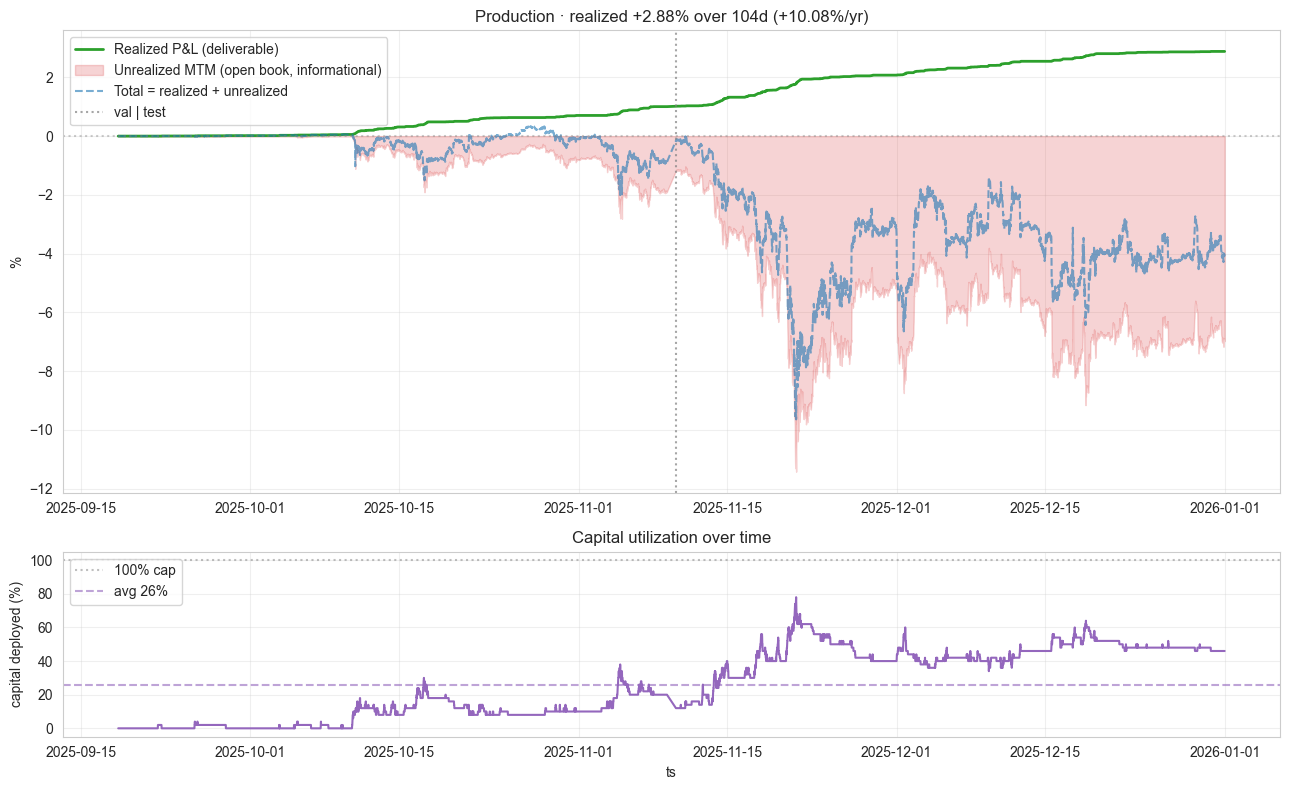

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production\production_equity.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [3, 1.2]})
ax = axes[0]
ax.plot(eq['ts'], eq['realized_cum']*100, color='C2', linewidth=2.0, label='Realized P&L (deliverable)')
ax.fill_between(eq['ts'], 0, eq['unrealized']*100, color='C3', alpha=0.20, label='Unrealized MTM (open book, informational)')
ax.plot(eq['ts'], total_eq*100, color='C0', linestyle='--', alpha=0.6, label='Total = realized + unrealized')
ax.axvline(val_test_boundary, color='gray', linestyle=':', alpha=0.7, label='val | test')
ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
ax.set(ylabel='%', title=f"Production · realized {float(daily.iloc[-1])*100:+.2f}% over {span_days:.0f}d ({annualized_realized*100:+.2f}%/yr)")
ax.legend(loc='upper left'); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(eq['ts'], eq['utilization']*100, color='C4')
ax2.axhline(100, color='gray', linestyle=':', alpha=0.5, label='100% cap')
ax2.axhline(avg_util*100, color='C4', linestyle='--', alpha=0.6, label=f'avg {avg_util*100:.0f}%')
ax2.set(ylabel='capital deployed (%)', xlabel='ts', title='Capital utilization over time')
ax2.legend(loc='upper left'); ax2.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / 'production_equity.png', dpi=150)
plt.show()
print(f"Saved: {OUT_DIR / 'production_equity.png'}")


## 6. Time-to-TP distribution (post-hoc characterization)

For every closed position, how long did the +phi limit take to fill? This
*does* peek at future paths and is therefore a post-hoc *characterization*
of the strategy's behavior, not anything the strategy uses live. Read it
as "how patient does this design demand".


percentile,hold_time
p10,2 min
p25,5 min
p50,14 min
p75,66 min (1.1 h)
p90,550 min (9.2 h)
p95,1752 min (1.2 d)
p99,8997 min (6.2 d)


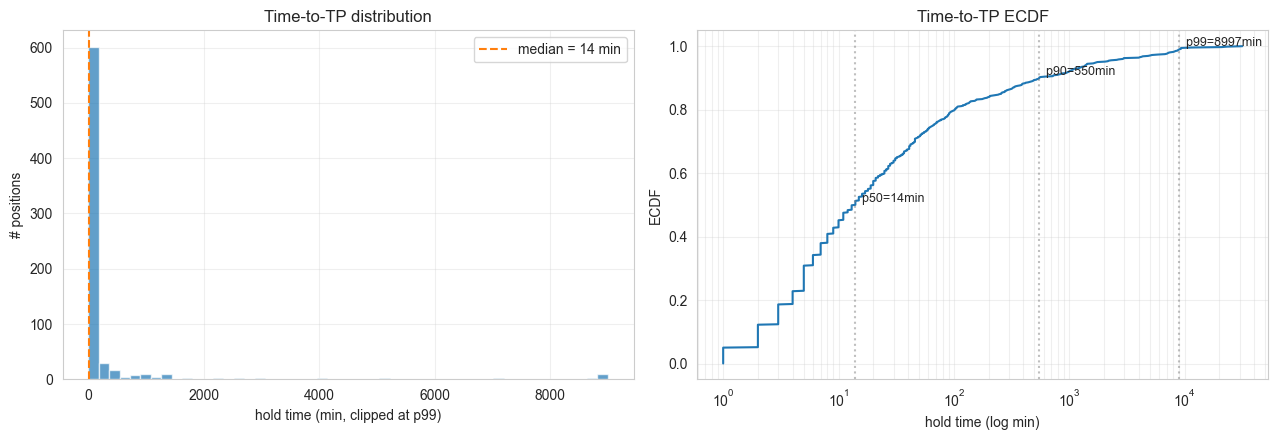

In [7]:
closed = result.closed.copy()
closed['ts_entry'] = pd.to_datetime(closed['ts_entry'].astype(str)).map(lambda x: x.tz_localize(None) if x.tzinfo is not None else x)
closed['ts_exit']  = pd.to_datetime(closed['ts_exit'].astype(str)).map(lambda x: x.tz_localize(None) if x.tzinfo is not None else x)
closed['hold_minutes'] = (closed['ts_exit'] - closed['ts_entry']).dt.total_seconds() / 60.0

rows = []
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    v = float(closed['hold_minutes'].quantile(q))
    if v < 60:   txt = f"{v:.0f} min"
    elif v < 1440: txt = f"{v:.0f} min ({v/60:.1f} h)"
    else:         txt = f"{v:.0f} min ({v/1440:.1f} d)"
    rows.append({'percentile': f'p{int(q*100)}', 'hold_time': txt})
display(pd.DataFrame(rows).style.hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
clip = float(closed['hold_minutes'].quantile(0.99))
axes[0].hist(closed['hold_minutes'].clip(upper=clip), bins=50, color='C0', alpha=0.7)
med = float(closed['hold_minutes'].median())
axes[0].axvline(med, color='C1', linestyle='--', label=f'median = {med:.0f} min')
axes[0].set(xlabel='hold time (min, clipped at p99)', ylabel='# positions', title='Time-to-TP distribution')
axes[0].legend(); axes[0].grid(alpha=0.3)

sorted_h = np.sort(closed['hold_minutes'].to_numpy())
ecdf = np.arange(1, len(sorted_h)+1) / len(sorted_h)
axes[1].semilogx(sorted_h, ecdf, color='C0')
for q, lab in [(0.50,'p50'), (0.90,'p90'), (0.99,'p99')]:
    v = float(closed['hold_minutes'].quantile(q))
    axes[1].axvline(v, color='gray', linestyle=':', alpha=0.5)
    axes[1].text(v, q, f'  {lab}={v:.0f}min', verticalalignment='bottom', fontsize=9)
axes[1].set(xlabel='hold time (log min)', ylabel='ECDF', title='Time-to-TP ECDF')
axes[1].grid(alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(OUT_DIR / 'time_to_tp.png', dpi=150)
plt.show()


## 7. Worst-MTM per closed position (post-hoc, paper-drawdown character)

For each closed position, how deep did the price go below entry *before*
the TP eventually fired? Median is shallow, but a small tail goes much
deeper. This is the risk the operator has to be sized against — not
because the loss gets realized (it doesn't), but because the open book
can show ugly MTM during the wait.


percentile,worst_mtm_bp
p5,-421 bp
p25,-75 bp
p50,-27 bp
p75,-8 bp
< -50 bp,35.0%
< -100 bp,20.0%
< -200 bp,11.0%
< -500 bp,4.2%
< -1000 bp,1.1%


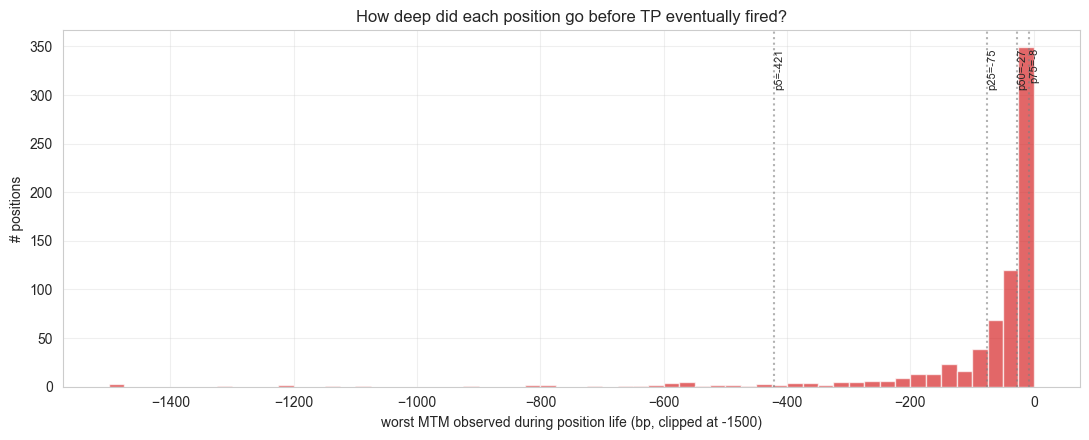

In [8]:
raw_idx_local = raw_bars.index.tz_localize(None) if raw_bars.index.tz is not None else raw_bars.index
raw_low = raw_bars['low'].to_numpy(dtype=float)
worst = []
for _, row in closed.iterrows():
    ts_in = pd.Timestamp(row['ts_entry']); ts_out = pd.Timestamp(row['ts_exit'])
    lo = int(np.searchsorted(raw_idx_local, np.datetime64(ts_in), side='right'))
    hi = int(np.searchsorted(raw_idx_local, np.datetime64(ts_out), side='right'))
    if hi <= lo:
        worst.append(0.0); continue
    worst.append(float(np.log(raw_low[lo:hi].min() / row['entry_price'])))
closed['worst_mtm_bp'] = np.asarray(worst) * 10000.0
rows = []
for q in [0.05, 0.25, 0.50, 0.75]:
    rows.append({'percentile': f'p{int(q*100)}', 'worst_mtm_bp': f"{closed['worst_mtm_bp'].quantile(q):+.0f} bp"})
for cutoff in [-50, -100, -200, -500, -1000]:
    rows.append({'percentile': f'< {cutoff:+5d} bp', 'worst_mtm_bp': f"{(closed['worst_mtm_bp'] < cutoff).mean()*100:.1f}%"})
display(pd.DataFrame(rows).style.hide(axis='index'))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(closed['worst_mtm_bp'].clip(lower=-1500, upper=0), bins=60, color='C3', alpha=0.7)
for q in [0.05, 0.25, 0.50, 0.75]:
    v = float(closed['worst_mtm_bp'].quantile(q))
    ax.axvline(v, color='gray', linestyle=':', alpha=0.6)
    ax.text(v, ax.get_ylim()[1]*0.95, f'p{int(q*100)}={v:.0f}', rotation=90, verticalalignment='top', fontsize=8)
ax.set(xlabel='worst MTM observed during position life (bp, clipped at -1500)', ylabel='# positions',
       title='How deep did each position go before TP eventually fired?')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / 'worst_mtm_per_position.png', dpi=150)
plt.show()


## 8. Capacity / lot-size sweep

For each `(max_open, lot_size)`: how many of the 744 signals do we actually
catch, what's the peak concurrent open book, and how deep does the
*observed* unrealized go in real-time? Below the natural ceiling
(`max_open >= 50`), every signal fires; above it we'd be allocating less
per signal but the picture stays the same.


In [9]:
def _make_spec(thr, lot, max_c):
    return StrategySpec(
        name=f'sweep_max{max_c}',
        score_fn=score_raw_p,
        entry_gates=(lambda s: gate_score_above(s, thr),),
        sizer=lambda s: size_clip(size_constant(s, default=lot), max_size=1.0),
        exit_policy=exit_tp_or_expiry,
        bulk_close=lambda s: None,
        risk=RiskConfig(
            cost_per_trade=COST,
            max_open_positions=max_c,
            max_gross_size=max_c*lot + 1e-6,
            max_horizon_boundaries=1_000_000,
            position_mtm_floor_log_return=None,
        ),
    )

cap_rows = []
for max_c, lot in [(5, 0.20), (10, 0.10), (20, 0.05), (50, 0.02), (100, 0.01), (200, 0.005)]:
    sp = _make_spec(THRESHOLD, lot, max_c)
    rr = simulate(sim_cache, raw_bars, sp, config=cfg)
    cap_rows.append({
        'max_open': max_c, 'lot': lot,
        'signals_taken': int(rr.equity['opened_this_step'].sum()),
        'TP_fills': int((rr.closed['exit_reason']=='tp').sum()) if len(rr.closed) else 0,
        'open_at_end': int(rr.equity['n_open'].iloc[-1]),
        'peak_concurrent': int(rr.equity['n_open'].max()),
        'realized_bp': float(rr.equity['realized_cum'].iloc[-1])*1e4,
        'min_unrealized_bp_observed': float(rr.equity['unrealized'].min())*1e4,
    })
cap_df = pd.DataFrame(cap_rows)
display(cap_df.style.format({
    'lot': '{:.3f}', 'realized_bp': '{:+.1f}',
    'min_unrealized_bp_observed': '{:+.1f}',
}).hide(axis='index'))
cap_df.to_csv(OUT_DIR / 'capacity_sweep.csv', index=False)
print(f"Saved: {OUT_DIR / 'capacity_sweep.csv'}")


max_open,lot,signals_taken,TP_fills,open_at_end,peak_concurrent,realized_bp,min_unrealized_bp_observed
5,0.200,65,60,5,5,+240.0,-3720.6
10,0.100,187,177,10,10,+354.0,-3070.3
20,0.050,406,386,20,20,+386.0,-2360.3
50,0.020,744,721,23,39,+288.4,-1142.6
100,0.010,744,721,23,39,+144.2,-571.3
200,0.005,744,721,23,39,+72.1,-285.7


Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\strategy\production\capacity_sweep.csv


## 9. What's still leaky and what to lock down

For full production rigor, three things would need to land before the
numbers above can be claimed without caveat:

1. **`THRESHOLD` should come from training-period `p` distribution**, not
   from offline analysis that informally peeked at val/test. To close
   this: score the train slice with the model, take its 90th percentile
   of `p`, freeze that value, replace the 0.30 here.

2. **The model itself was HPO'd in notebook 03 with visibility into val**.
   No strategy-layer fix can clean that up. To close it: a proper
   nested-CV HPO inside the training period only.

3. **Walk-forward refresh of the threshold**. The fixed 0.30 doesn't
   adapt to drift. In production, refresh it monthly from the trailing
   month's training-period score distribution. (The streaming-quantile
   primitive in `src/strategy/online.py` makes this a one-line addition.)

If you want me to land any of these, point at one.
